In [4]:
import pandas as pd
import numpy as np
import scipy.io as sio
import torch
import sys, os
project_root = os.path.abspath(os.path.join(os.getcwd(), os.pardir))
if project_root not in sys.path:
    sys.path.insert(0, project_root)
from data_classes.decomposition import Extract_Features, PCA_features
import torchaudio

In [5]:
data_P1 = sio.loadmat('../data/mine_impact_data_2019.mat')
samps = pd.DataFrame(data_P1['x'].T)
labs  = pd.DataFrame(data_P1['y'].T, columns=['y'])
df_P1 = pd.concat([samps, labs], axis=1).dropna().sample(frac=1, random_state=42)
shuffled_df = df_P1.sample(frac=1, random_state=42).reset_index(drop=True)
df_X_P1 = shuffled_df.iloc[:, :-1]
df_Y_P1 = shuffled_df.iloc[:, -1]
data_P1 = Extract_Features(df_X_P1, df_Y_P1, feature="raw")


data_P2 = sio.loadmat('../data/phase2_data_20220215.mat')
samps = pd.DataFrame(data_P2['x'].T)
labs  = pd.DataFrame(data_P2['y'].T, columns=['y'])
df_P2 = pd.concat([samps, labs], axis=1).dropna().sample(frac=1, random_state=42)
bad_indices = [
    100,303,496,507,609,706,909,1011,1113,1271,1373,1475,1577,1679,1781,1883,2085,2287,
    2389,2489,2789,2891,2895,2995,3096,3497,3767,3997,4099,4201,4499,4699,5199,5301,
    5302,5500,7688,7690,7691,7692,7696,7702,7704,7708,7715,7723,7727,7810,7841,7870,
    7888,7936,7941,7965,7997,8061,8080,8081,8095,8098,8124,8125,8126,8127,8128,8132,
    8156,8157,8158,8159,8160,8161,8215,8261,8302,8310,8322,8395,8425,8477,8478,8479,
    8483,8487,8491,8496,8527,8563,8587,8642,8743,8848,
    0,94,98,102,203,403,505,607,611,708,809,1009,1111,1171,1273,1473,1575,1579,1635,
    1660,1674,1681,1881,1983,1985,2087,2088,2187,2246,2387,2589,2689,2791,2893,3196,
    3455,3495,3696,3798,3999,4199,4701,4748,4749,4798,4999,5201,5209,5244,5245,5255,
    5924,5945,5977,6128,6135,6229,6271,6299,6377,6383,6388,6389,6678,6760,6903,6906,
    6935,6936,7430,7582,7694,7698,7699,7700,7706,7710,7713,7717,7718,7777,7778,7856,
    7872,7939,7943,7960,7984,7999,8046,8048,8059,8063,8064,8068,8078,8083,8084,8085,
    8093,8165,8166,8191,8308,8366,8397,8398,8481,8485,8489,8493,8494,8498,8544,8565,
    8640,8692,8798,8902
]
df_P2 = df_P2.drop(index=bad_indices, errors='ignore')
shuffled_df = df_P2.sample(frac=1, random_state=42).reset_index(drop=True)
df_X_P2 = shuffled_df.iloc[:, :-1]
df_Y_P2 = shuffled_df.iloc[:, -1]
data_P2 = Extract_Features(df_X_P2, df_Y_P2, feature="raw")


print("Phase 1 data shape:", data_P1.get_samples().shape)
print("Phase 2 data shape:", data_P2.get_samples().shape)

Phase 1 data shape: (3309, 36000)
Phase 2 data shape: (8229, 4800)


In [ ]:
import models.classification as classify
import models.loops as loops
import models.models as models

train_idx = list(range(0, 3000))
test_idx = list(range(3000,3309))

train_data = torch.utils.data.Subset(data_P1, train_idx)
test_data = torch.utils.data.Subset(data_P1, test_idx)

batch_size = 30

train_loader = torch.utils.data.DataLoader(train_data, batch_size=batch_size, shuffle=True)
test_loader = torch.utils.data.DataLoader(test_data, batch_size=batch_size, shuffle=True)

model = models.Convolution_Combined()
epochs = 25

loops.train(model=model, model_path="./model_paths/convolution.pth", train_loader=train_loader,val=False,val_loader=None, batch_size=batch_size, lr=1e-3,weight_decay=0, optim="adam", epochs=epochs, device="cpu")

loops.test(model_path="./model_paths/convolution.pth", test_loader=test_loader, report=True, device="cpu")

In [ ]:
##Train and test previous model with Phase 2 data
import models.classification as classify
import models.loops as loops
import models.models as models

train_idx = list(range(0, 7500))
test_idx = list(range(7500,8229))

train_data = torch.utils.data.Subset(data_P2, train_idx)
test_data = torch.utils.data.Subset(data_P2, test_idx)

batch_size = 30

train_loader = torch.utils.data.DataLoader(train_data, batch_size=batch_size, shuffle=True)
test_loader = torch.utils.data.DataLoader(test_data, batch_size=batch_size, shuffle=True)

model = models.Convolution_Combined()
model.load_state_dict(torch.load("./model_paths/convolution.pth"))
epochs = 25

loops.train(model=model, model_path="./model_paths/convolution.pth", train_loader=train_loader,val=False,val_loader=None, batch_size=batch_size, lr=1e-3,weight_decay=0, optim="adam", epochs=epochs, device="cpu")

loops.test(model_path="./model_paths/convolution.pth", test_loader=test_loader, report=True, device="cpu")

In [9]:

df_combined = pd.concat([df_P1, df_P2], ignore_index=True, axis=0).fillna(0.0001)

df_train = df_combined.iloc[:10000].sample(frac=1, random_state=42).reset_index(drop=True)
df_X_combined_train = df_train.iloc[:, :-1]
df_Y_combined_train = df_train.iloc[:, -1]

data_combined_train = Extract_Features(df_X_combined_train, df_Y_combined_train, feature="raw")

df_test = df_combined.iloc[10000:].sample(frac=1, random_state=42).reset_index(drop=True)
df_X_combined_test = df_test.iloc[:, :-1]
df_Y_combined_test = df_test.iloc[:, -1]
data_combined_test = Extract_Features(df_X_combined_test, df_Y_combined_test, feature="raw")



print("Train data shape:", data_combined_train.get_samples().shape)
print("Test data shape:", data_combined_test.get_samples().shape)


Train data shape: (10000, 36000)
Test data shape: (1538, 36000)


[INFO] EPOCH: 1/50
Train loss: 0.665961, Train accuracy: 0.6095
[INFO] EPOCH: 2/50
Train loss: 0.635270, Train accuracy: 0.6573
[INFO] EPOCH: 3/50
Train loss: 0.610758, Train accuracy: 0.6756
[INFO] EPOCH: 4/50
Train loss: 0.591322, Train accuracy: 0.6861
[INFO] EPOCH: 5/50
Train loss: 0.574359, Train accuracy: 0.6994
[INFO] EPOCH: 6/50
Train loss: 0.558611, Train accuracy: 0.7066
[INFO] EPOCH: 7/50
Train loss: 0.546721, Train accuracy: 0.7180
[INFO] EPOCH: 8/50
Train loss: 0.539120, Train accuracy: 0.7239
[INFO] EPOCH: 9/50
Train loss: 0.526797, Train accuracy: 0.7321
[INFO] EPOCH: 10/50
Train loss: 0.511920, Train accuracy: 0.7412
[INFO] EPOCH: 11/50
Train loss: 0.500847, Train accuracy: 0.7482
[INFO] EPOCH: 12/50
Train loss: 0.495139, Train accuracy: 0.7484
[INFO] EPOCH: 13/50
Train loss: 0.477856, Train accuracy: 0.7569
[INFO] EPOCH: 14/50
Train loss: 0.470852, Train accuracy: 0.7611
[INFO] EPOCH: 15/50
Train loss: 0.462437, Train accuracy: 0.7724
[INFO] EPOCH: 16/50
Train loss: 0.

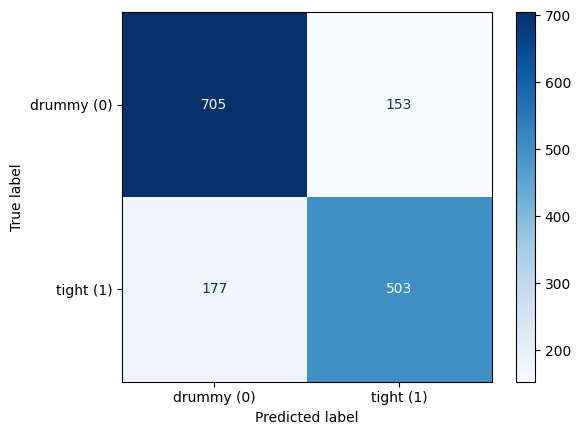


Classification Report:
               precision    recall  f1-score   support

  drummy (0)       0.80      0.82      0.81       858
   tight (1)       0.77      0.74      0.75       680

    accuracy                           0.79      1538
   macro avg       0.78      0.78      0.78      1538
weighted avg       0.78      0.79      0.78      1538



In [12]:

train_idx = list(range(0, len(data_combined_train.get_samples())))
test_idx = list(range(0, len(data_combined_test.get_samples())))
import models.classification as classify
import models.loops as loops
import models.models as models
loops.train(model=models.Convolution_Combined(), model_path="./model_paths/convolution_combined.pth", train_loader=torch.utils.data.DataLoader(torch.utils.data.Subset(data_combined_train, train_idx), batch_size=30, shuffle=True), val=False, val_loader=None, batch_size=30, lr=1e-3, weight_decay=0, optim="adam", epochs=50, device="mps")
loops.test(model = models.Convolution_Combined(),model_path="./model_paths/convolution_combined.pth", test_loader=torch.utils.data.DataLoader(torch.utils.data.Subset(data_combined_test, test_idx), batch_size=30, shuffle=True), report=True, device="mps")